In [ ]:
from PySpectral import *

In [28]:
# superposição equiprovável para os 3 primeiros níveis:
coeficientes = [1, 1, 1] + [0]*497 

# intervalo de tempo considerado:
# [0, 100]
tempo = 100.0

# total de pontos calculados dentro do intervalo:
pontos = 300

# -------------------------------------------------
#                   k = 1
# -------------------------------------------------

# Parâmetros do sistema físico
k = 1
l = -15                     # lambda
b = 0.27                    # beta
s = 0.9999                  # sigma

m = (6*(b+2))/s             # massa
omega = ((2*k)/(b+2))**0.5  # omega

# a função 'f' define o potencial do problema.
def f(x):
    return (m**2)*(omega**2) - 4*l*m*x

# a função 'g'.
def g(x):
    return 2*m

# a função 'w' define a função peso do problema.
def w(x):
    return 1

# definindo o objeto (configuração do problema)
# optimizer_L == y -> as contas serão feitas com o L otimizado.
p = SpectralMethod(num_levels=500, 
                   length=10, 
                   f_function=f, 
                   g_function=g, 
                   weight=w, 
                   num_digits=15, 
                   root_filename='Strings', 
                   label="Strings", 
                   optimizer_L='y')

# descrevendo o problema
p.is_described()


Directory 'Strings' created successfully.
Optimizing the box length. Please wait…

L OPTIMIZATION
Number of basis functions: N = 500
Limits: L ∈ [0.1, 50.0]

[OPTIMIZATION] N=500 | Range=[0.10, 50.00]
  > Grid Min: 31.49103211909501
  > Tolerance: 3.15e-11
  > Strategy: PLATEAU (Left Edge Optimization)
  > Target Start: L=1.6121
  > Final Result: L=2.037612 (E=31.49103211909456)

Result: L_opt = 2.037611624151854
Optimized length: L = 2.037612 (N=500)
--------------------------------------------------------------------------------
Number of energy levels:       500
Interval amplitude (Length):   2.0376116241518543 (float: 2.0376116241518543)
f function (V_spectral):       (m**2)*(omega**2) - 4*l*m*x
g function:                    2*m
w function (weigth):           1
Label:                         Strings
Number of digits to be used:   15
The energy spectrum has not been calculated yet.
--------------------------------------------------------------------------------
Important: when usin

In [29]:
# calculando a energia E0 e o L ótimo
#p.optimize_length()


In [30]:
# resolve o problema
p.is_solved()

Calculating eigenvalues ...
________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: Strings/Strings_Spectrum.txt
Time elapsed for eigenvalues calculation: 0.365963 seconds.
Calculating eigenvectors ...
________________________________________________________________________________
Calculating energy eigenvectors now ...
Eigenvectors saved to: Strings/Strings_Eigenvectors.txt
________________________________________________________________________________
Done!
Time elapsed for eigenvectors calculation: 0.738377 seconds.
The eigenvalue/eigenvector problem has been completely solved with 15 digits used.


In [31]:
# 10 primeiros autovalores
p.its_eigenvalues(slice(1, 11))

[np.float64(13.502911978551785),
 np.float64(19.117650072302215),
 np.float64(23.714483353000258),
 np.float64(27.777187724054315),
 np.float64(31.491032119096456),
 np.float64(34.95168277377658),
 np.float64(38.21662199722839),
 np.float64(41.32377756674942),
 np.float64(44.29982935094149),
 np.float64(47.16444236421051)]

In [32]:
# 10  primeiros autovetores
vec = p.its_eigenvectors(slice(1, 11))

In [33]:
spec = p.calculate_spectrum()

________________________________________________________________________________
Calculating energy eigenvalues...
________________________________________________________________________________
Finished eigenvalue calculation.
________________________________________________________________________________
Spectrum saved to: Strings/Strings_Spectrum.txt


Eigenpairs saved in: Strings/Strings_Eigenpairs.txt
--- Processing 3 levels ---
-> Saved TXT: Level 0
-> Saved TXT: Level 1
-> Saved TXT: Level 2
-> Image saved: Strings/Strings_eigenfunctions.png


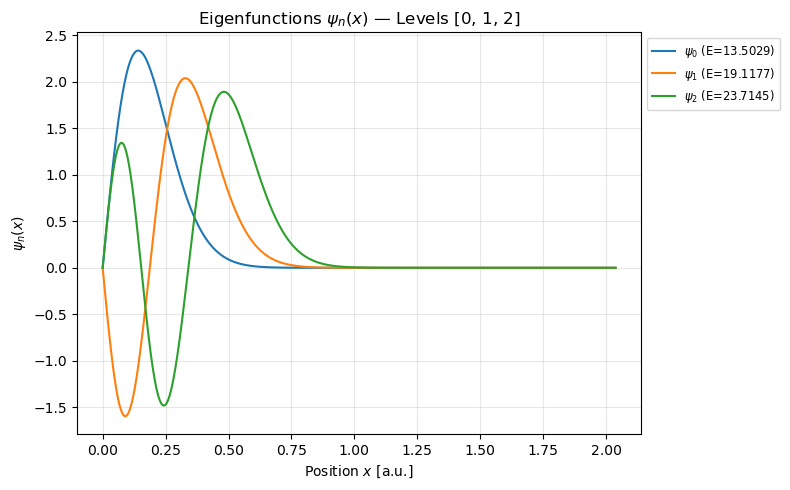

In [34]:
p.plot_eigenfunctions(num_levels=3)

In [35]:
# calculando a posição esperada
p.expected_position_is_calculated((0.0, tempo), coeficientes, pontos)

Calculating 300 points.
Data on expected position has been stored in file: Strings/Strings_Position.txt


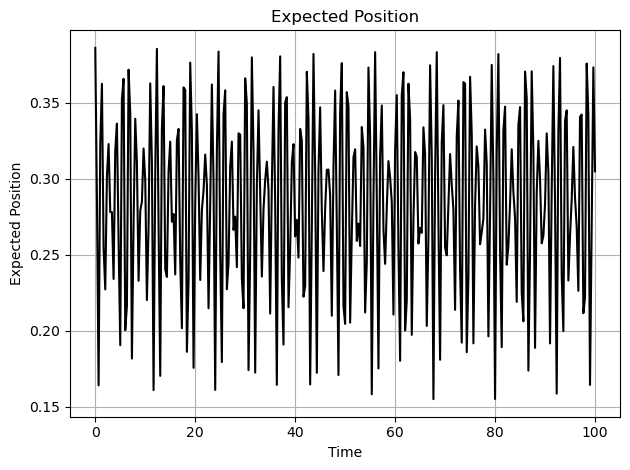

In [36]:
# gráfico da posição esperada
p.expected_position_is_plotted()

In [37]:
# salvando em um arquivo 'txt'
# colunas do arquivo:
#    (1)Time  t
#    (2)Expected position  <x>
#    (3)Expected position – uncertainty (delta1)
#    (4)Expected position + uncertainty (delta2)
# intervalo de tempo: (0, 10)
# usando o valor padrão de subintervalos: 100):

p.expected_position_and_uncertainty_are_calculated((0.0, tempo), coeficientes, pontos)

Expected position and uncertainty data stored in file: Strings/Strings_PositionUncertainty.txt


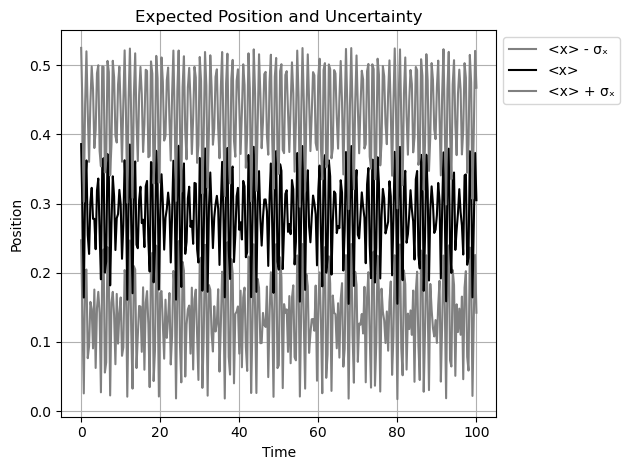

In [38]:
# gráfico da posição esperada vs incerteza 
p.expected_position_and_uncertainty_are_plotted()

In [ ]:
# salvando em um arquivo 'txt'
# colunas do arquivo:
#    (1) Time
#    (2) Expected momentum  
#    (3) Expected momentum – uncertainty  
#    (4) Expected momentum + uncertainty 
# intervalo de tempo: (0, 10)
# usando o valor padrão de subintervalos: 100):

p.expected_momentum_and_uncertainty_are_calculated((0.0, tempo), coeficientes, pontos)

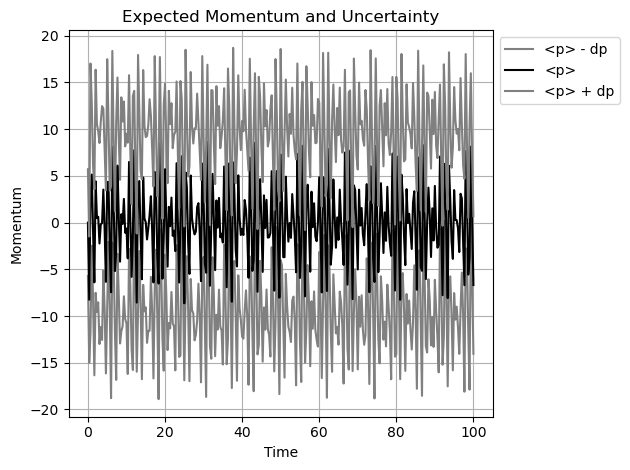

In [ ]:
# gráfico do momento vs incerteza 
p.expected_momentum_and_uncertainty_are_plotted()

Minimum value of dx(t) / <x>(t): 0.357580581101959
Estimated period(s): 
t = 64.882943143812710
Full results saved at: t100/t100_min_relative_uncertainty.txt


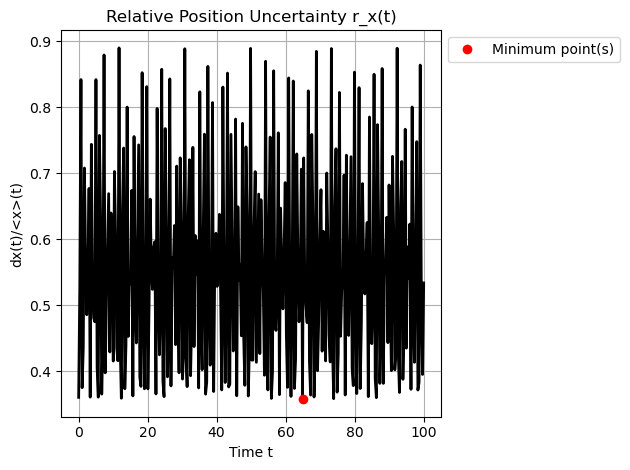

(<Figure size 640x480 with 1 Axes>,
 np.float64(0.35758058110195895),
 [np.float64(64.88294314381271)])

In [ ]:
# gráfico da incerteza relativa a posição (tempo entre 0 e 100)
p.position_uncertainty_relative(coeficientes, t_max=tempo, num_points=pontos)

Computing density frames…


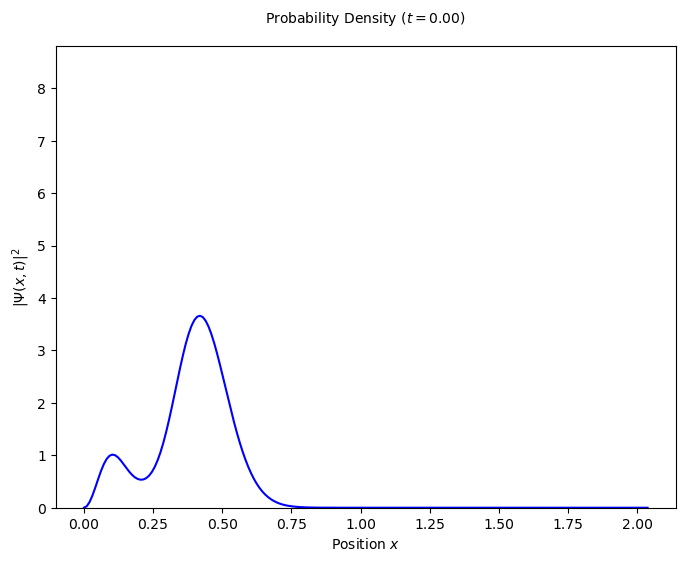

In [ ]:
p.probability_density_is_plotted((0.0, tempo), coeficientes)

In [ ]:
n = p.norm_of_wave_function(coeficientes)

for t in np.linspace(0, tempo, 100):
    print(f"Norm at t= {t:.1f}: {n(t):.15}")

Norm at t= 0.0: 1.00000000000016
Norm at t= 1.0: 1.00000000000013
Norm at t= 2.0: 1.00000000000013
Norm at t= 3.0: 1.00000000000017
Norm at t= 4.0: 1.00000000000015
Norm at t= 5.1: 1.00000000000016
Norm at t= 6.1: 1.00000000000016
Norm at t= 7.1: 1.00000000000014
Norm at t= 8.1: 1.00000000000017
Norm at t= 9.1: 1.00000000000014
Norm at t= 10.1: 1.00000000000011
Norm at t= 11.1: 1.00000000000016
Norm at t= 12.1: 1.00000000000015
Norm at t= 13.1: 1.00000000000013
Norm at t= 14.1: 1.00000000000017
Norm at t= 15.2: 1.00000000000016
Norm at t= 16.2: 1.00000000000016
Norm at t= 17.2: 1.00000000000016
Norm at t= 18.2: 1.00000000000013
Norm at t= 19.2: 1.00000000000016
Norm at t= 20.2: 1.00000000000015
Norm at t= 21.2: 1.00000000000011
Norm at t= 22.2: 1.00000000000015
Norm at t= 23.2: 1.00000000000016
Norm at t= 24.2: 1.00000000000014
Norm at t= 25.3: 1.00000000000016
Norm at t= 26.3: 1.00000000000016
Norm at t= 27.3: 1.00000000000016
Norm at t= 28.3: 1.00000000000016
Norm at t= 29.3: 1.00000

In [ ]:
p.check_solutions_numerically()

Building matrices for verification...
Reporting errors in equations in file: t100/t100_Check_Equations.txt
Reporting errors in eigenvector normality in file: t100/t100_Check_Normality.txt
Reporting errors in eigenvector orthogonality in file: t100/t100_Check_Orthogonality.txt
Numerical verification Done.


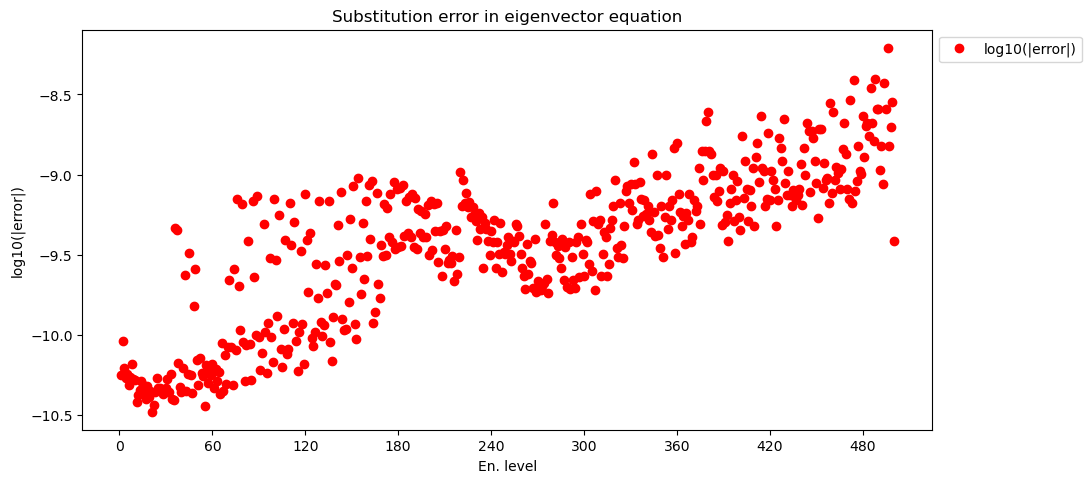

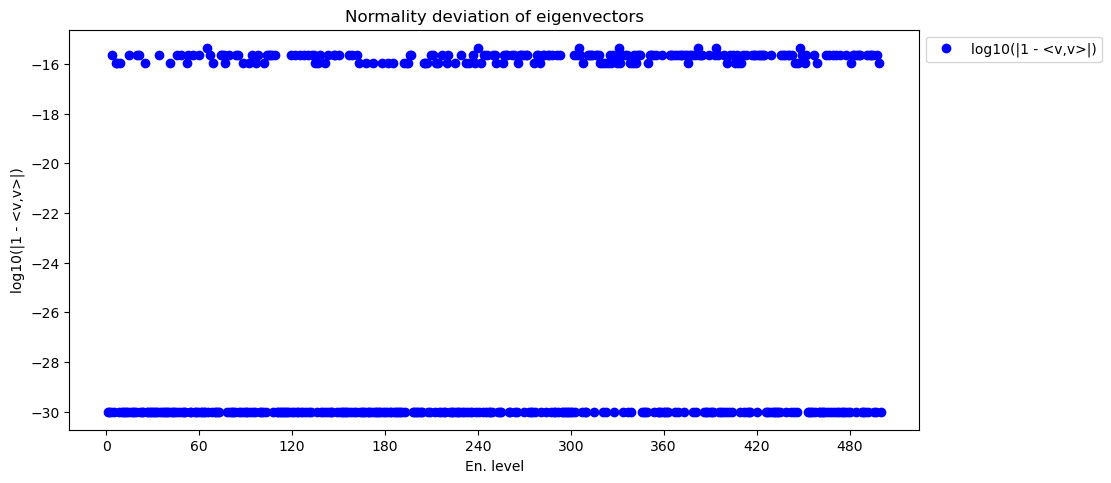

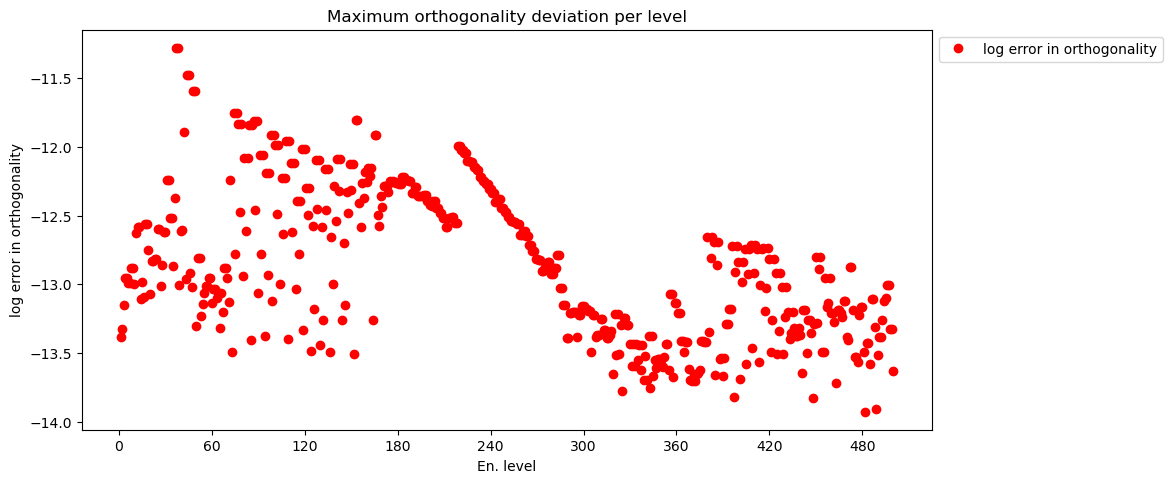

--------------------------------------------------------------------------------
---------------- Orthogonality Summary (2D curve) ----------------


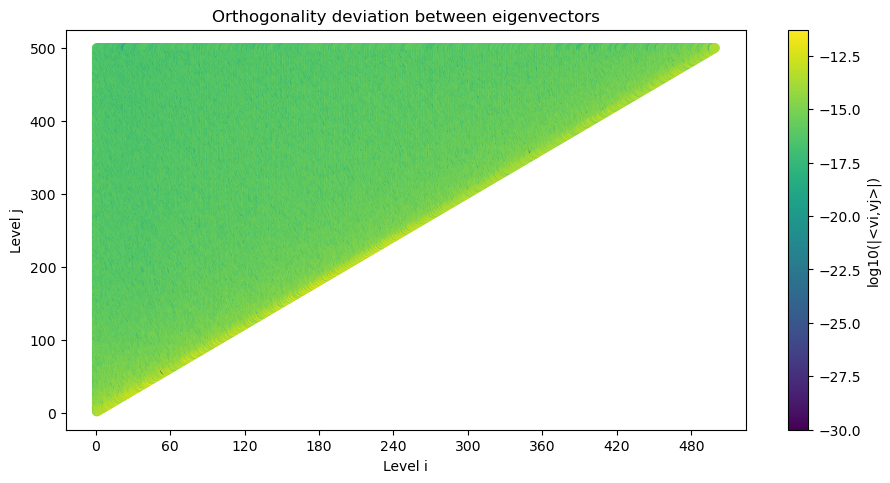

Graphical check Done.


In [ ]:
p.check_solutions_graphically()

In [ ]:
import numpy as np
from scipy.special import ai_zeros

def calcular_espectro_energia(n_niveis=10):
    # --- 1. Constantes Físicas ---
    k = 1
    l = -15.0      # Lambda
    b = 0.27       # Beta
    s = 0.9999     # Sigma

    # --- 2. Parâmetros Derivados ---
    m = (6 * (b + 2)) / s
    omega = np.sqrt((2 * k) / (b + 2))

    # --- 3. Obtenção das Raízes (r_n) ---
    # ai_zeros retorna as raízes da função de Airy (Ai)
    # O índice [0] pega apenas os zeros (a_n), ignorando as derivadas.
    r_values = ai_zeros(n_niveis)[0]

    # --- 4. Cálculo da Energia (Eq. 20) ---
    print(f"{'n':<4} | {'Raiz (r_n)':<12} | {'Energia (E_n)':<15}")
    print("-" * 35)

    energias = []

    for n, r_n in enumerate(r_values):
        # Termo constante: (m/2) * w^2
        termo_1 = (m / 2) * omega**2

        # Termo variável: cbrt(2/m) * Lambda^(2/3) * r_n
        # Nota: Usamos np.cbrt(l**2) para garantir que o resultado seja real
        termo_2 = np.cbrt(2 / m) * np.cbrt(l**2) * r_n

        # Eq (20): E_n = Termo1 - Termo2
        # Como r_n é negativo, o '-' com '-' resultará em uma soma, aumentando a energia.
        E_n = termo_1 - termo_2
        
        energias.append(E_n)
        print(f"{n:<4} | {r_n:<12.4f} | {E_n:.15f}")
    
    return energias

# Executar o cálculo para os 10 primeiros níveis
lista_energias = calcular_espectro_energia(10)

n    | Raiz (r_n)   | Energia (E_n)  
-----------------------------------
0    | -2.3381      | 13.502911978552044
1    | -4.0879      | 19.117650072300627
2    | -5.5206      | 23.714483352999462
3    | -6.7867      | 27.777187724054841
4    | -7.9441      | 31.491032119069736
5    | -9.0227      | 34.951682773776149
6    | -10.0402     | 38.216621997227236
7    | -11.0085     | 41.323777566749108
8    | -11.9360     | 44.299829350934822
9    | -12.8288     | 47.164442363754304


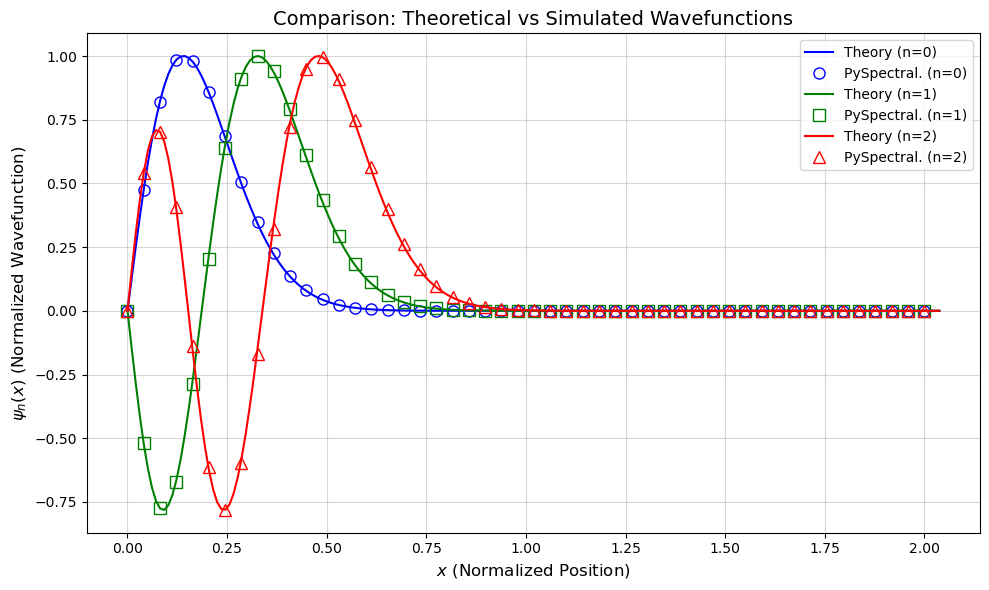

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy, ai_zeros
import os

# --- Configurações Iniciais ---
# Nomes dos arquivos (ajuste conforme o nome real dos seus arquivos)
filenames = [
    't100/t100_psi_level_0.txt', 
    't100/t100_psi_level_1.txt', 
    't100/t100_psi_level_2.txt'
]

# Cores e marcadores para cada nível (0, 1, 2)
styles = [
    {'color': 'blue', 'marker': 'o', 'label': 'n=0'},
    {'color': 'green', 'marker': 's', 'label': 'n=1'},
    {'color': 'red', 'marker': '^', 'label': 'n=2'}
]

# Fator de escala para o argumento da função de Airy (Teórico)
# O argumento é z = scale_factor * x + root_n
# Esse valor "7.5" é um chute inicial baseado no domínio x ~ 0.8. 
# Você pode precisar ajustar levemente para casar perfeitamente com sua simulação.
SCALE_FACTOR = 9.4 

def get_theoretical_curve(x_array, n):
    """
    Gera a função de onda teórica (Airy) normalizada.
    Psi_n(x) ~ Ai(scale * x + a_n)
    """
    # Obtém os zeros da função de Airy (a_n são negativos)
    # ai_zeros(nt) retorna (a, a', b, b'). Queremos 'a'.
    roots, _, _, _ = ai_zeros(n + 1) 
    root = roots[n] # O n-ésimo zero (ex: -2.33 para n=0)
    
    # O argumento z começa no zero da função (para x=0 -> Psi=0) e aumenta
    z = SCALE_FACTOR * x_array + root
    psi_theory, _, _, _ = airy(z)
    
    # Inverter sinal se necessário (funções de onda têm fase arbitrária)
    # A função de Airy começa positiva para z < 0.
    psi_theory = psi_theory / np.max(np.abs(psi_theory))
    
    return psi_theory

# --- Plotagem ---
plt.figure(figsize=(10, 6))

for n, filename in enumerate(filenames):
    if not os.path.exists(filename):
        print(f"Aviso: Arquivo {filename} não encontrado. Pulando nível {n}.")
        continue
    
    # 1. Carregar Dados Simulados
    # comments='#' ignora os cabeçalhos do seu arquivo
    data = np.loadtxt(filename, comments='#')
    x_sim = data[:, 0]
    psi_sim = data[:, 1]
    
    # Normalizar dados simulados (para garantir pico em 1.0 ou -1.0)
    psi_sim = psi_sim / np.max(np.abs(psi_sim))
    
    # 2. Gerar Dados Teóricos
    # Usamos um x denso para a linha ficar suave
    x_theory = np.linspace(min(x_sim), max(x_sim), 200)
    psi_theory = get_theoretical_curve(x_theory, n)
    
    # Ajuste de sinal (se a simulação estiver invertida em relação à teoria)
    # Comparamos o sinal no ponto de máximo absoluto
    idx_max = np.argmax(np.abs(psi_sim))
    if np.sign(psi_sim[idx_max]) != np.sign(psi_theory[np.argmax(np.abs(psi_theory))]):
        psi_theory *= -1

    # 3. Plotar
    style = styles[n]
    
    # Linha Teórica (Sólida)
    plt.plot(x_theory, psi_theory, 
             color=style['color'], 
             linestyle='-', 
             linewidth=1.5,
             label=f'Theory ({style["label"]})')
    
    # Pontos Simulados (Marcadores Vazios)
    # step=15 serve para não poluir o gráfico com muitos pontos
    step = max(1, len(x_sim) // 50) 
    plt.plot(x_sim[::step], psi_sim[::step], 
             color=style['color'], 
             marker=style['marker'], 
             linestyle='None', 
             markerfacecolor='none', 
             markeredgewidth=1.0,
             markersize=8, # Tamanho do marcador
             markevery=1,
             label=f'PySpectral. ({style["label"]})')

# --- Estilização Final ---
plt.xlabel(r'$x$ (Normalized Position)', fontsize=12)
plt.ylabel(r'$\psi_n(x)$ (Normalized Wavefunction)', fontsize=12)
plt.title('Comparison: Theoretical vs Simulated Wavefunctions', fontsize=14)
plt.grid(True, which='both', linestyle='-', alpha=0.5)
plt.legend(loc='best', frameon=True, fontsize=10)
plt.tight_layout()

plt.show()